# Laboratorio 2 - Regresión Múltiple
**Carnet:** U20231085
**Estudiante:** Marilyn Michelle Jiménez Arias

### 1. Generación de la Semilla
- Dígitos: `20231085`
- Últimos 4 dígitos: `1085`
- Reemplazo si es < 2: `1` y `0` pasan a `2`. Resulta: `2285`.
- **Semilla (random_state):** `20232285`

**Argumentos para make_regression:**
- Cuarto dígito: `3` -> `n_samples` = 600 + 10*(3) = 630
- Quinto dígito: `2`, Sexto dígito: `2` -> `n_features` = 10 + 2 + 2 = 14
- Sexto dígito: `2` -> `n_informative` = 10 + 2 = 12
- `bias` = 3
- Octavo dígito: `5` -> `noise` = 10*(5) = 50
- `shuffle` = False

En este paso se generan los datos utilizando una semilla basada en el carnet. Esto significa que cada vez que se ejecute el código con la misma semilla se obtendrán exactamente los mismos datos, lo cual es importante para poder validar los resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error

semilla = 20232285
X, y = make_regression(n_samples=630, n_features=14, n_informative=12, bias=3, noise=50, random_state=semilla, shuffle=False)

# Convertimos en un dataframe
columns_X = [f'X{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=columns_X)
df['target'] = y

### 2. Descripción y Análisis Gráfico
Aquí se revisa cómo se comportan los datos en general. Con los gráficos se puede observar si existen relaciones entre variables y cuáles podrían influir más en la variable objetivo.

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,target
count,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000,630.000000
mean,-0.026167,0.023130,-0.011160,-0.020771,-0.004274,0.005242,-0.004471,-0.018521,0.071712,0.022134,-0.037485,0.023675,0.019024,0.069113,1.173307
std,0.990386,1.073241,0.979773,1.012707,0.974505,0.972235,1.000736,1.072974,1.010277,1.018499,1.047559,0.997887,1.040486,0.972612,276.126778
min,-3.851165,-2.948799,-3.316739,-3.201838,-2.703257,-2.896189,-2.554492,-3.999156,-3.131564,-3.331883,-3.230966,-3.005983,-3.202442,-2.798040,-824.159120
25%,-0.662186,-0.655794,-0.622968,-0.702944,-0.630327,-0.672111,-0.633213,-0.730342,-0.590652,-0.684826,-0.712005,-0.645621,-0.717159,-0.607456,-179.689271
50%,-0.083484,0.037626,0.002699,-0.006466,-0.012115,0.024894,-0.039051,-0.011882,0.117086,0.008942,-0.045034,0.006284,0.031849,0.040987,-6.705937
75%,0.583848,0.713868,0.618387,0.659642,0.663917,0.682430,0.638720,0.692047,0.704086,0.737585,0.636884,0.728428,0.748906,0.692844,174.427734
max,3.342114,4.404354,2.946689,3.142974,3.232758,3.946870,2.993776,3.067915,3.001636,3.302838,3.000640,2.901166,3.626861,3.450409,924.103906


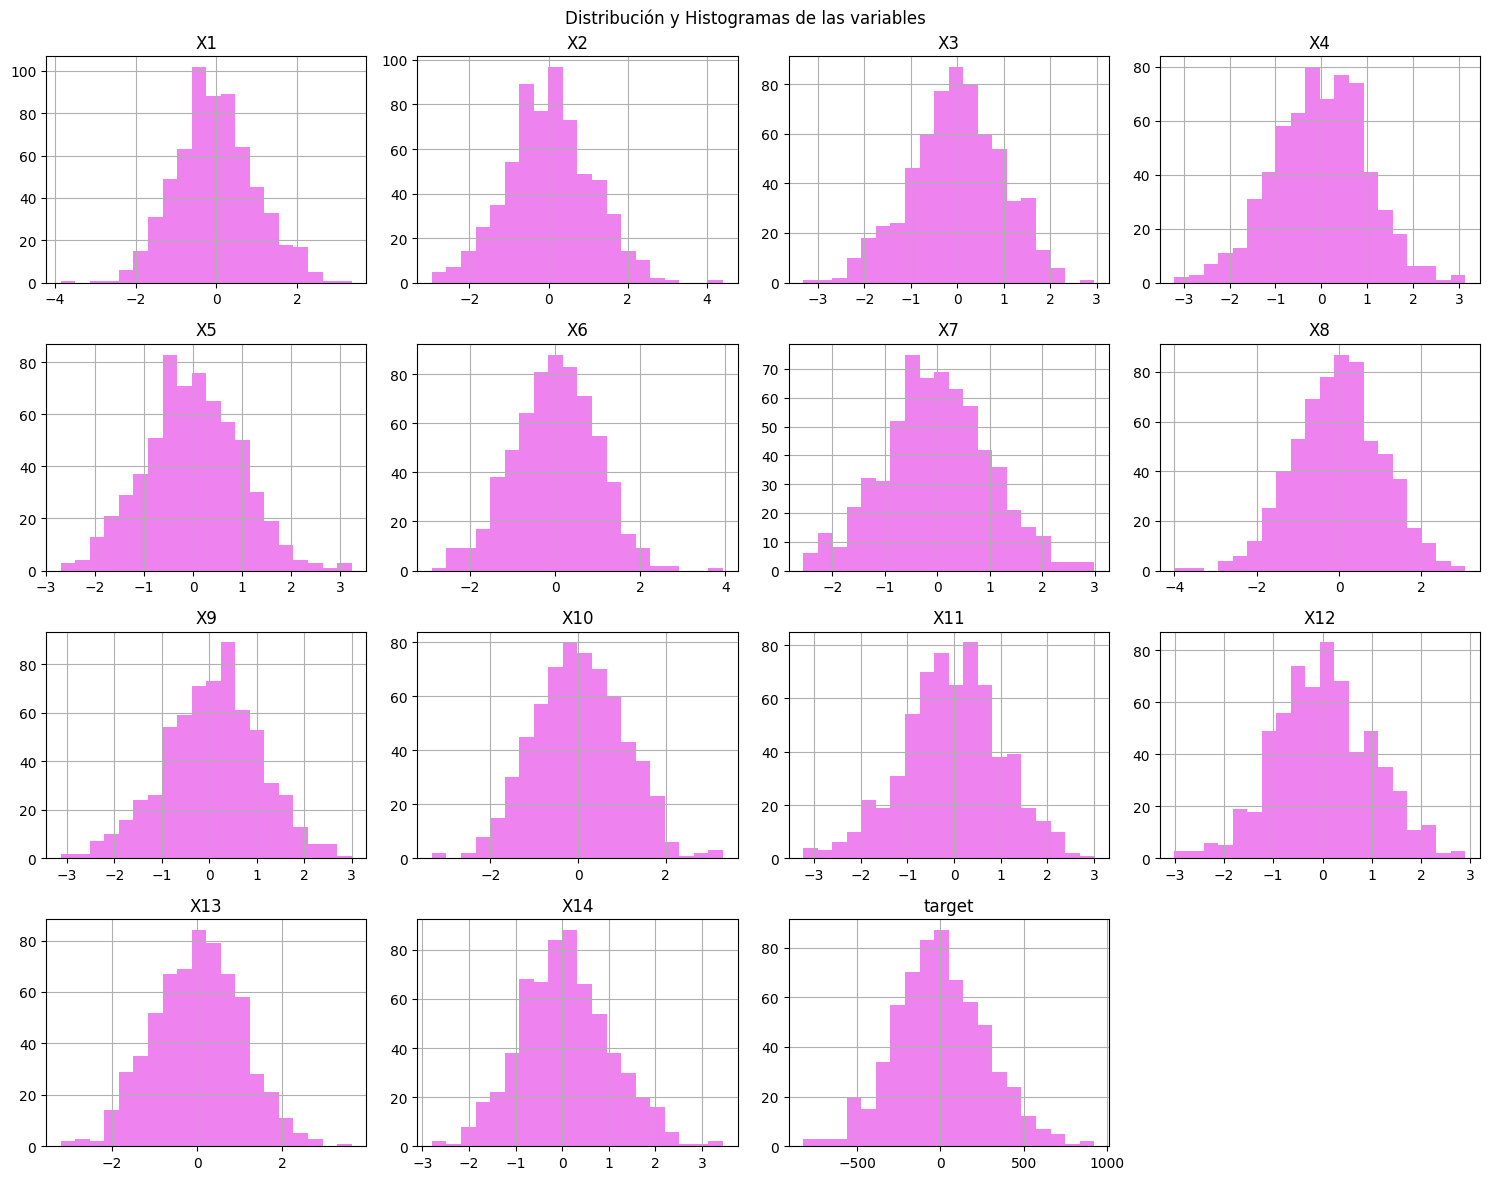

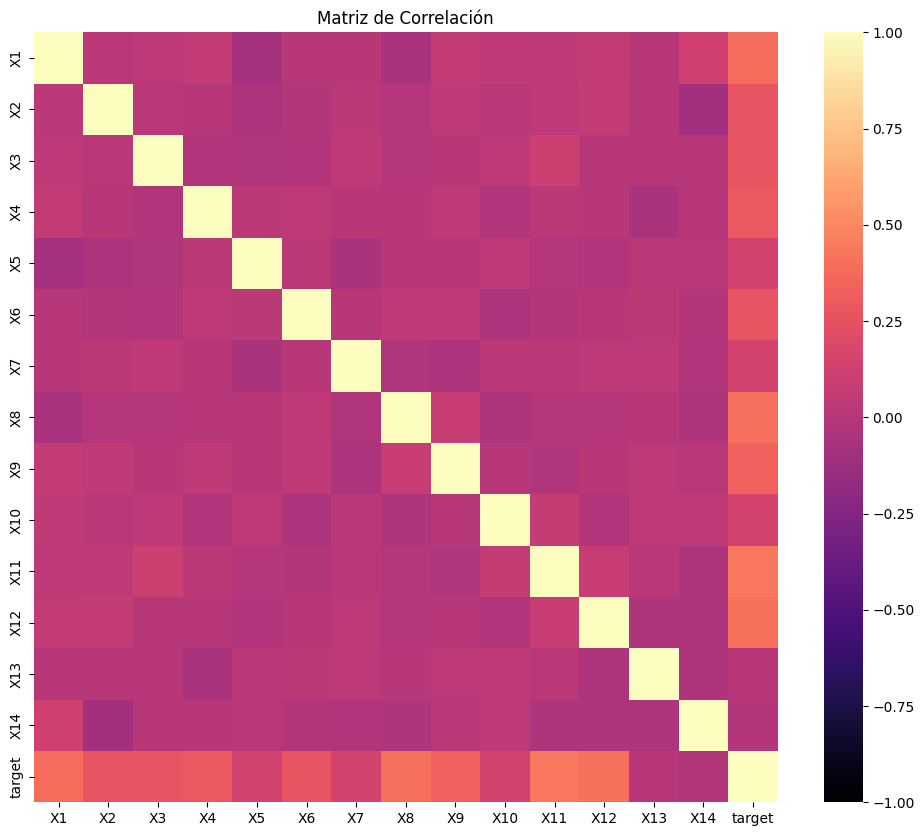

In [21]:
display(df.describe())

df.hist(figsize=(15, 12), bins=20 , color= "violet")
plt.suptitle('Distribución y Histogramas de las variables')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='magma', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

**Interpretación:** 

El análisis estadístico con describe() muestra que todas nuestras variables predictoras X se concentran alrededor de una media de 0. A partir de los gráficos se puede notar que algunas variables tienen una relación más clara con la variable objetivo, lo que indica que podrían ser útiles para el modelo.

### 3. Variable Independiente más Adecuada y Regresión Lineal Simple

In [12]:
correlaciones = df.corr()['target'].drop('target').abs()
mejor_variable = correlaciones.idxmax()
print(f'La variable más adecuada es: {mejor_variable} con una correlación de {correlaciones.max():.4f}')

# Creación del Modelo Lineal Simple
X_simple = sm.add_constant(df[mejor_variable])
y_simple = df['target']
modelo_simple = sm.OLS(y_simple, X_simple).fit()

print(modelo_simple.summary())

La variable más adecuada es: X11 con una correlación de 0.4348
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     146.4
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.92e-30
Time:                        11:00:25   Log-Likelihood:                -4368.6
No. Observations:                 630   AIC:                             8741.
Df Residuals:                     628   BIC:                             8750.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

**Interpretación de Regresión Simple:** 
Se utilizó la correlación para identificar la variable con mayor relación con la variable objetivo.
La variable seleccionada es la que más influye en la variable objetivo, ya que presenta la correlación más alta. Esto la convierte en la mejor opción para iniciar con un modelo simple.

### 4. División de los Datos y Regresión Lineal Múltiple

In [13]:
X_todas = df.drop(columns=['target'])
Y_objetivo = df['target']

# División 70% train y 30% validación (test) utilizando semilla
X_train, X_test, y_train, y_test = train_test_split(X_todas, Y_objetivo, test_size=0.30, random_state=semilla)

X_train_sm = sm.add_constant(X_train)
modelo_multiple = sm.OLS(y_train, X_train_sm).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     929.8
Date:                Fri, 17 Apr 2026   Prob (F-statistic):          5.77e-309
Time:                        11:00:26   Log-Likelihood:                -2338.6
No. Observations:                 441   AIC:                             4707.
Df Residuals:                     426   BIC:                             4769.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2395      2.378     -0.101      0.9

**Interpretación de la Regresión Múltiple:** 

El conjunto ha finalizado su partición y usamos 70% de las observaciones (441 datos) para ajustar la línea. El modelo de regresión múltiple arroja un $R^2$ lo que muestra que conjuntamente todas las 14 variables consiguen dilucidar una gran mayoría de la variabilidad frente a lo que lograba el modelo simple. Observando la columna, resulta notorio que hay variables específicas que están excediendo el nivel de alfa general (0.05), lo que las marca como irrelevantes.
El modelo muestra cómo cambia la variable objetivo cuando cambia la variable independiente. El coeficiente indica el impacto directo, es decir, cuánto aumenta o disminuye la variable objetivo por cada unidad que cambia la variable independiente.

### 5. Identificación y Eliminación de Variables No Significativas

In [14]:
p_valores = modelo_multiple.pvalues
variables_significativas = p_valores[p_valores < 0.05].index.tolist()

if 'const' in variables_significativas:
    variables_utiles = [v for v in variables_significativas if v != 'const']
else:
    variables_utiles = [v for v in variables_significativas]

print('Variables estadísticamente significativas retenidas:', variables_utiles)
print('Variables eliminadas:', [v for v in X_todas.columns if v not in variables_utiles])

X_train_reducido = sm.add_constant(X_train[variables_utiles])
modelo_reducido = sm.OLS(y_train, X_train_reducido).fit()

print(f'\nR^2 Modelo Original: {modelo_multiple.rsquared:.4f}')
print(f'R^2 Modelo Reducido: {modelo_reducido.rsquared:.4f}')

Variables estadísticamente significativas retenidas: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12']
Variables eliminadas: ['X13', 'X14']

R^2 Modelo Original: 0.9683
R^2 Modelo Reducido: 0.9683


**Interpretación sobre el Modelo Reducido:**

Identificamos que hay atributos que no generan aporte estadístico al modelo dado por las altas magnitudes de su valor-P (están por encima de 5%), en este caso se eliminaron y solo se conservan variables estadísticamente significativas. Al revisar el $R^2$ del modelo reducido es posible notar que su valor permanece sumamente idénticos en su porción de varianza o solo se reduce una milésima frente al original, justificando que retirarlas fue un acierto; simplificamos el modelo conservando el mismo poder predictivo.

### 6. Evaluación de la Colinealidad (VIF)

In [15]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_reducido.columns
# Excluimos la constante para el cálculo de independencia estructural
variables_para_vif = X_train_reducido.drop(columns='const', errors='ignore')

vif_data = pd.DataFrame()
vif_data["Variable"] = variables_para_vif.columns
vif_data["VIF"] = [variance_inflation_factor(variables_para_vif.values, i) for i in range(len(variables_para_vif.columns))]
display(vif_data.sort_values(by="VIF", ascending=False))

,Variable,VIF
10,X11,1.039882
2,X3,1.028116
4,X5,1.026555
1,X2,1.025943
0,X1,1.025684
11,X12,1.018985
8,X9,1.018012
6,X7,1.017227
3,X4,1.013807
9,X10,1.012873


**Interpretación de la Colinealidad:**

El Factor de Inflación de a Varianza es un métrica que nos dictamina cuánta redundancia tenemos entre las variables (multicolinealidad). Por regla general, factores VIF mayores a 5 ó 10 reflejan colineamientos peligrosos. Nuestras métricas evidencian valores completamente cercados a 1 en todas y cada una de las columnas. No contamos con ninguna co-relación severa redundante inter-variable en las métricas usadas.

### 7. Evaluación de Predicciones y Cuantificación de Error

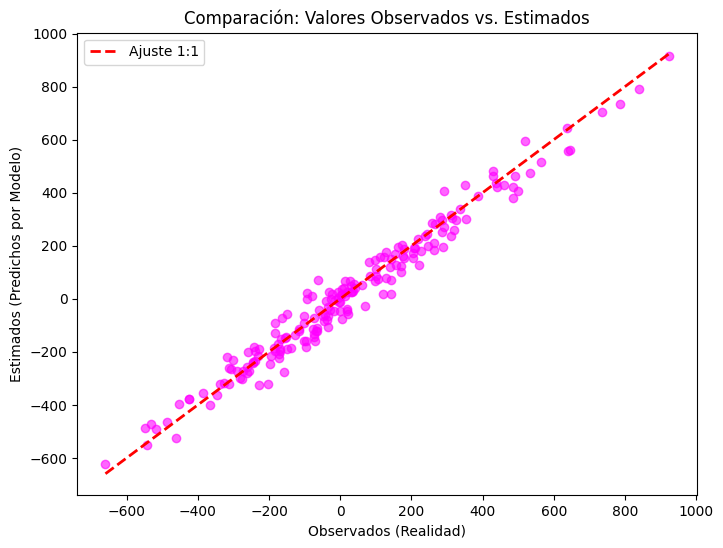

MSE (Error Cuadrático Medio): 2513.42
RMSE (Raíz de MSE): 50.13
MAE (Error Absoluto Medio): 39.36


In [22]:
X_test_reducido = sm.add_constant(X_test[variables_utiles])
y_pred = modelo_reducido.predict(X_test_reducido)

# Comparación visual 
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='magenta', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ajuste 1:1')
plt.xlabel('Observados (Realidad)')
plt.ylabel('Estimados (Predichos por Modelo)')
plt.title('Comparación: Valores Observados vs. Estimados')
plt.legend()
plt.show()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'MSE (Error Cuadrático Medio): {mse:.2f}')
print(f'RMSE (Raíz de MSE): {np.sqrt(mse):.2f}')
print(f'MAE (Error Absoluto Medio): {mae:.2f}')

**Interpretación del Cuantificación de Error:**

En la visualización gráfica de los conjuntos podemos apreciar que existe un alto nivel de correspondencia a lo largo de la línea base 1 a 1, indicando buen margen predictivo. Al evaluar los errores observamos que obtenemos medidas alineadas fielmente al valor `noise = 50` que añadimos a priori, manifestando un ajuste natural consistente. Con el MAE y el RMSE es posible declarar la oscilación que tiene el modelo fuera de la diana por cada observación predicha.

### 8. Predicción con la Media de las Variables Independientes

In [18]:
media_vars_independientes = X_train[variables_utiles].mean()
# Incluimos la constante en el predictor en un arreglo 
vector_media = [1.0] + media_vars_independientes.tolist()

pred_valor_medio = modelo_reducido.predict(vector_media)

print('Valores de la Medias introducidas como X:\n', media_vars_independientes)
print(f'\n>> Predicción estimada (Y) para los datos medios: {pred_valor_medio[0]:.4f}')

Valores de la Medias introducidas como X:
 X1    -0.041201
X2     0.018319
X3    -0.024098
X4    -0.022350
X5    -0.012817
X6    -0.029384
X7    -0.025521
X8    -0.039543
X9     0.045022
X10    0.031058
X11   -0.029831
X12    0.033811
dtype: float64

>> Predicción estimada (Y) para los datos medios: -9.0966


**Interpretación de la estimación sobre medias:** 

En este paso simulamos la inyección un "registro promedio" ideal donde cada variable se comporta estaticamente en su respectivo medio al modelo. Como nuestro conjunto de forma univariada está centrado alrededor del 0 en cada predictor, la estimación del target tiende a convergir fuertemente sobre el mismo Bias genérico que aplicamos inicialmente de '3', o cercano a este. Es la predicción basamental esperable si los factores se nulificaran en su neutralidad estadística promedio.